In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from utils import load_images_from_path

images, names = load_images_from_path("../data/undistorted")

pairs = [
    ["set_1_1.jpg", "set_1_2.jpg"],
    ["set_2_1.jpg", "set_2_2.jpg"],
    ["set_3_1.jpg", "set_3_2.jpg"],
]
image_pairs = []
for name1, name2 in pairs:
    img1 = images[names.index(name1)]
    img2 = images[names.index(name2)]
    image_pairs.append((img1, img2))

This can be used to display images to choose pairs of points from them.

To do that you should uncomment the code and choose the pair for which you want to select points.

In [3]:
# import cv2

# img1, img2 = image_pairs[1]

# cv2.imshow("Image 2", img2)
# cv2.imshow("Image 1", img1)
# while cv2.getWindowProperty("Image 1", cv2.WND_PROP_VISIBLE) >= 1 and cv2.getWindowProperty("Image 2", cv2.WND_PROP_VISIBLE) >= 1:
#     cv2.waitKey(100)
# cv2.destroyAllWindows()

### Find transformation matrices

In [4]:
import pandas as pd

df = pd.read_csv("../data/selected_points/point_pairs.csv", skipinitialspace=True)

In [5]:
from projective_transformation import find_transformation

Hs = []

for s in range(1, 4):
    df_s = df[df["set"] == s]
    points1 = df_s[["x1", "y1"]].to_numpy()
    points2 = df_s[["x2", "y2"]].to_numpy()
    Hs.append(find_transformation(points1, points2))

### Project second image onto the first one

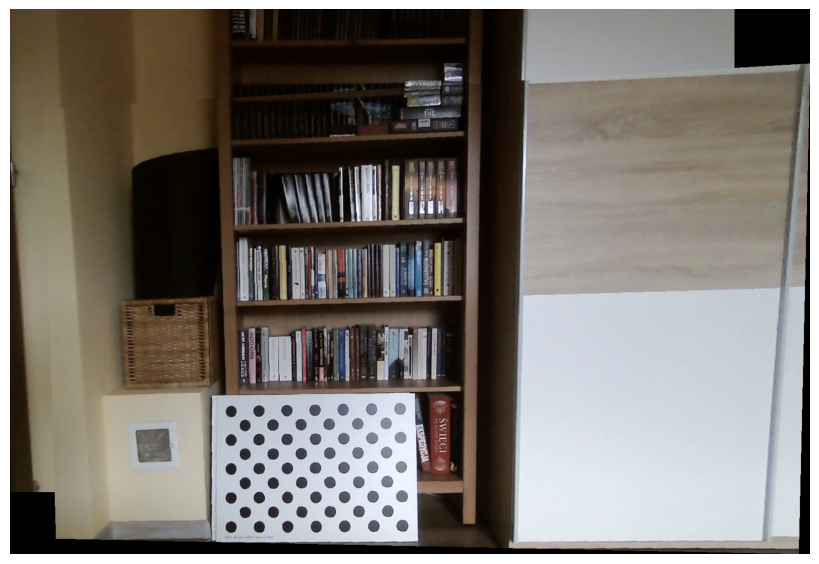

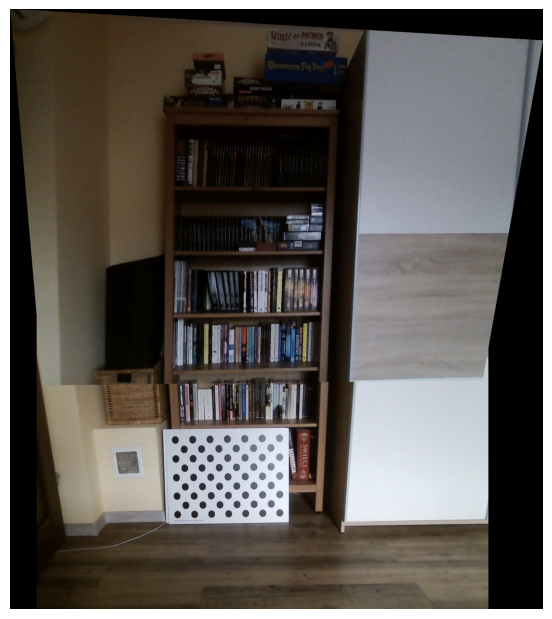

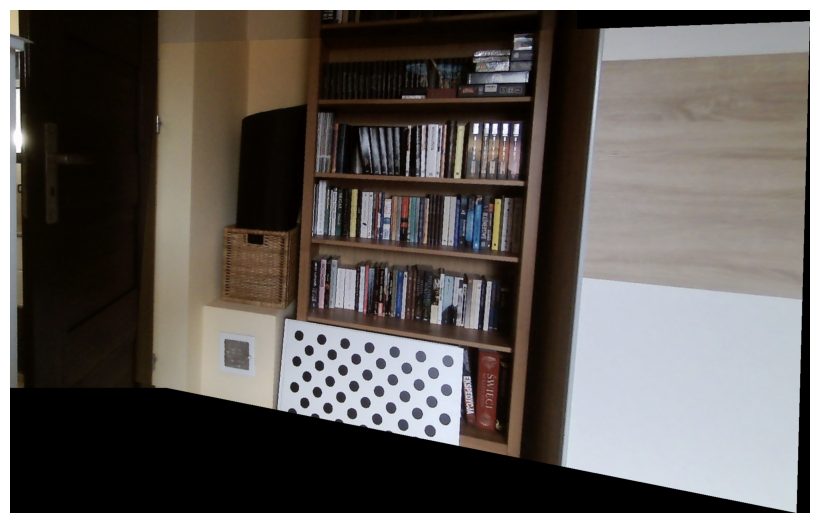

In [6]:
from projective_transformation import project_on_plane
import utils

i = 1
for (img1, img2), H in zip(image_pairs, Hs):
    warped_img1 = project_on_plane(img1, H, img2)
    utils.plot_img(warped_img1)
    utils.save_image(
        warped_img1, f"../data/hand_selected_points/simple_projection/pair_{i}.png"
    )
    i += 1

### Use linear stitching to combine both images

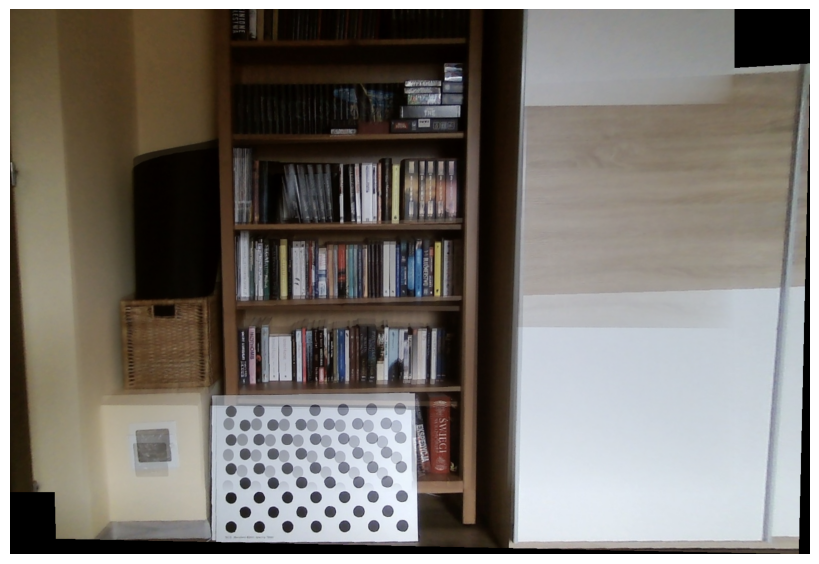

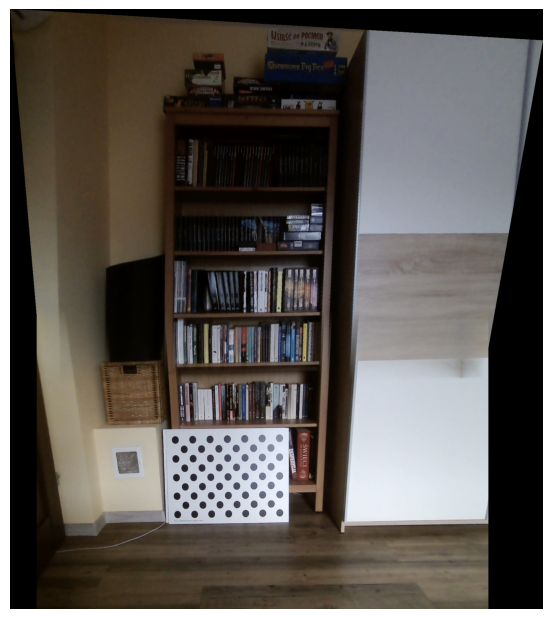

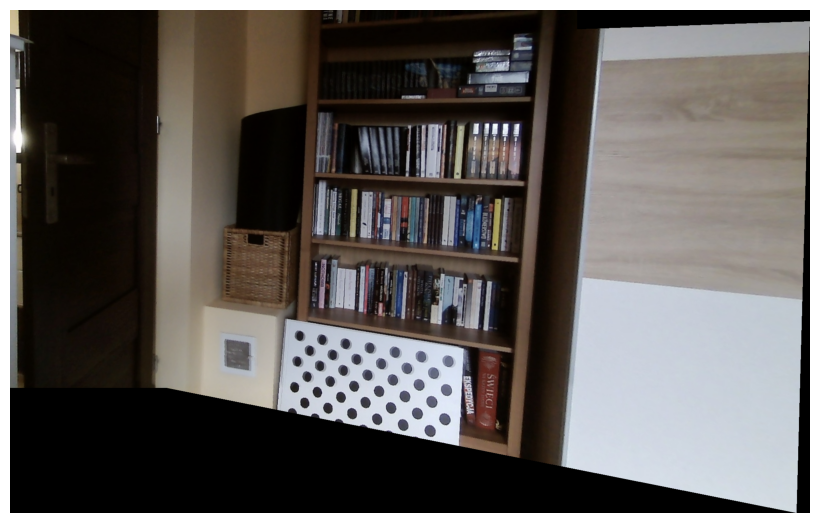

In [7]:
from projective_transformation import linear_stitching

i = 1
for (img1, img2), H in zip(image_pairs, Hs):
    stitched_img = linear_stitching(img1, H, img2)
    utils.plot_img(stitched_img)
    utils.save_image(
        stitched_img, f"../data/hand_selected_points/linear_stitching/pair_{i}.png"
    )
    utils.save_image(stitched_img, f"../data/results/task_5_stitched_pair_{i}.jpg")
    i += 1